# Setup

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import classification_report

# Exploratory Data Analysis

In [4]:
# ingest dataset
df = pd.read_csv('Base.csv')

## Understanding the Dataset

In [8]:
# check for shape
df.shape

(176868, 32)

In [9]:
# checks for missingness
df.isna().sum().sort_values(ascending = False)

,0
foreign_request,1
source,1
session_length_in_minutes,1
device_os,1
keep_alive_session,1
month,1
device_distinct_emails_8w,1
device_fraud_count,1
proposed_credit_limit,1
bank_months_count,1


## Train-test Split

In [25]:
y = df['fraud_bool'].values
X = df['credit_risk_score'].values.reshape(-1,1)

In [13]:
pd.Series(y).describe()

,fraud_bool
count,176868.000000
mean,0.010686
std,0.102819
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

# Model Training

In [41]:
# model training

models = {"Logistic Regression": LogisticRegression(),
          "KNN": KNeighborsClassifier()}
results_train = []
results_test = []


for model in models.values():
    kf = KFold(n_splits = 6, shuffle = True, random_state = 42)

    cv_scores = cross_val_score(model, X = X_train, y = y_train, cv = kf)
    results_train.append(cv_scores)

    y_pred = model.fit(X_train, y_train).predict(X_test)
    print(classification_report(y_test, y_pred))

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           0       0.99      1.00      0.99     34996
           1       0.00      0.00      0.00       378

    accuracy                           0.99     35374
   macro avg       0.49      0.50      0.50     35374
weighted avg       0.98      0.99      0.98     35374

              precision    recall  f1-score   support

           0       0.99      1.00      0.99     34996
           1       0.00      0.00      0.00       378

    accuracy                           0.99     35374
   macro avg       0.49      0.50      0.50     35374
weighted avg       0.98      0.99      0.98     35374



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


/tmp/ipykernel_1858/3951867299.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(results_train, labels = models.keys())


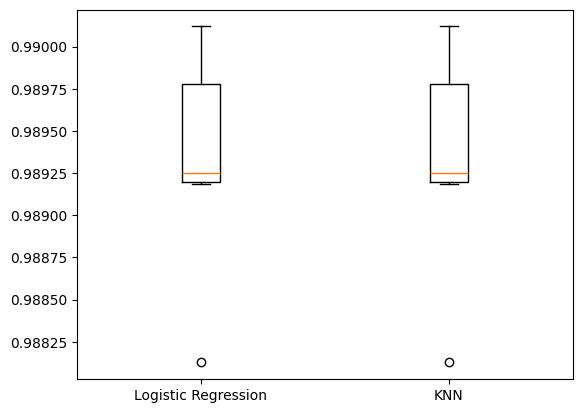

In [32]:
plt.boxplot(results_train, labels = models.keys())
plt.show()

# Next Steps
- Feature Engineering
- Hyperparameter Tuning
- Follow Instructions from NeurIPS2022